Pulling results from both notebooks to join the together

In [1]:
import nbformat
from nbconvert.preprocessors import ExecutePreprocessor
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import re

In [2]:
def load_notebook(notebook_path):
    with open(notebook_path, 'r') as f:
        nb = nbformat.read(f, as_version=4)

    # Execute the notebook in an isolated environment
    ep = ExecutePreprocessor(timeout=600, kernel_name='python3')
    ep.preprocess(nb, {'metadata': {'path': './'}})  # Run notebook in current directory
    globals_dict = {}
    exec("\n".join(cell.source for cell in nb.cells if cell.cell_type == "code"), globals_dict)
    if "sequence_df" in globals_dict:
        return globals_dict["sequence_df"]
    else:
        raise ValueError(f"'sequence_df' not found in {notebook_path}")

# Load DataFrames from both notebooks
directionality_df = load_notebook('directionality.ipynb')
time_between_detections_df = load_notebook('time_between_detections.ipynb')


Category '1': ['11', '12', '13']
Category '2': ['201', '202', '21', '22', '231', '232', '233']
Category '3': ['301', '302', '3A', '3B']
Category '4': ['401', '402', '41', '42', '44', '45']
Category '5': ['501', '51', '5A', '5B']
Category '6': ['61', '62', '6A', '6B', '6C', '6D', '6F']
Category '7': ['701', '702', '71', '7A', '7B', '7C', '7D']
Category '8': ['81', '82', '83', '84']
Category '9': ['91', '92', '921', '922', '9A', '9B', '9C', '9D', '9F']
Category 'others': ['A1', 'A2', 'AA', 'AB', 'C1', 'C2', 'E1', 'E2']
            tag_id                           0
0         0.000061       {'loc_code': ['701']}
1         0.000081       {'loc_code': ['701']}
2         0.000174        {'loc_code': ['21']}
3         0.000183       {'loc_code': ['702']}
4         3.237301        {'loc_code': ['11']}
...            ...                         ...
109059  989.002028        {'loc_code': ['C1']}
109060  989.002028  {'loc_code': ['C2', 'C1']}
109061  989.005135        {'loc_code': ['9C']}
109062 

<string>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
<string>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

            tag_id                                      sequence_data
0         0.000061  {'loc_code': ['701'], 'time_between_detections...
1         0.000081  {'loc_code': ['701'], 'time_between_detections...
2         0.000174  {'loc_code': ['21'], 'time_between_detections'...
3         0.000183  {'loc_code': ['702'], 'time_between_detections...
4         3.237301  {'loc_code': ['11'], 'time_between_detections'...
...            ...                                                ...
109059  989.002028  {'loc_code': ['C1'], 'time_between_detections'...
109060  989.002028  {'loc_code': ['C2', 'C1'], 'time_between_detec...
109061  989.005135  {'loc_code': ['9C'], 'time_between_detections'...
109062  990.000004  {'loc_code': ['501'], 'time_between_detections...
109063  997.131499  {'loc_code': ['6B'], 'time_between_detections'...

[109064 rows x 2 columns]


In [3]:
directionality_df

,tag_id,loc_code,movement_direction
0,0.000061,[701],[]
1,0.000081,[701],[]
2,0.000174,[21],[]
3,0.000183,[702],[]
4,3.237301,[11],[]
...,...,...,...
109059,989.002028,[C1],[]
109060,989.002028,"[C2, C1]",[ds]
109061,989.005135,[9C],[]
109062,990.000004,[501],[]


In [4]:
time_between_detections_df

,tag_id,loc_code,time_between_locations,number_of_detections,dwell_time
0,0.000061,[701],[NaT],[1],[0 days 00:00:00]
1,0.000081,[701],[NaT],[1],[0 days 00:00:00]
2,0.000174,[21],[NaT],[1],[0 days 00:00:00]
3,0.000183,[702],[NaT],[1],[0 days 00:00:00]
4,3.237301,[11],[NaT],[1],[0 days 00:00:00]
...,...,...,...,...,...
109059,989.002028,[C1],[NaT],[4],[0 days 00:03:00.020000]
109060,989.002028,"[C2, C1]","[0 days 00:54:12.480000, NaT]","[4, 1]","[0 days 00:02:59.920000, 0 days 00:00:00]"
109061,989.005135,[9C],[NaT],[2],[0 days 00:00:00]
109062,990.000004,[501],[NaT],[4],[430 days 23:41:50.140000]


In [5]:
time_between_detections_df = time_between_detections_df.drop(columns=["loc_code"])  
merged_df = directionality_df.merge(time_between_detections_df, on="tag_id")  
merged_df = merged_df[['tag_id', 'loc_code', 'number_of_detections', 'dwell_time', 'movement_direction', 'time_between_locations']]
merged_df

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_locations
0,0.000061,[701],[1],[0 days 00:00:00],[],[NaT]
1,0.000081,[701],[1],[0 days 00:00:00],[],[NaT]
2,0.000174,[21],[1],[0 days 00:00:00],[],[NaT]
3,0.000183,[702],[1],[0 days 00:00:00],[],[NaT]
4,3.237301,[11],[1],[0 days 00:00:00],[],[NaT]
...,...,...,...,...,...,...
109059,989.002028,[C1],[4],[0 days 00:03:00.020000],[],[NaT]
109060,989.002028,"[C2, C1]","[4, 1]","[0 days 00:02:59.920000, 0 days 00:00:00]",[ds],"[0 days 00:54:12.480000, NaT]"
109061,989.005135,[9C],[2],[0 days 00:00:00],[],[NaT]
109062,990.000004,[501],[4],[430 days 23:41:50.140000],[],[NaT]


In [6]:
merged_df.to_csv("../data/tag summaries.csv", index=False)

In [7]:
unusual = merged_df[merged_df["movement_direction"].apply(lambda x: "unknown" in x)]
unusual

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_locations
32,956.000005,"[6A, 61, 61, 6A, 61]","[5, 6, 12, 1, 548]","[2 days 10:58:30.360000, 1 days 20:15:12.63000...","[ds, unknown, us, ds]","[21 days 16:26:32.950000, 698 days 02:14:13.63..."
34,956.000006,"[6A, 501]","[11, 116]","[0 days 02:55:09.300000, 886 days 23:37:28.230...",[unknown],"[217 days 18:46:49.710000, NaT]"
69,982.000403,"[202, 202, 201, 201]","[5, 5, 1, 1]","[0 days 03:35:48.040000, 0 days 03:35:48.04000...","[unknown, ds, unknown]","[-1 days +20:24:11.960000, 0 days 02:11:10.240..."
73,982.000403,"[202, 202]","[6, 6]","[22 days 10:38:54.260000, 22 days 10:38:54.260...",[unknown],"[-23 days +13:21:05.740000, NaT]"
102,982.000403,"[202, 202, 201, 201]","[117, 117, 1, 1]","[22 days 06:42:16.580000, 22 days 06:42:16.580...","[unknown, ds, unknown]","[-23 days +17:17:43.420000, 0 days 04:23:29.08..."
...,...,...,...,...,...,...
105939,989.002028,"[922, 9D, 9C, 9D, 9C, 9D, 9C, 9D]","[1, 1, 4, 8, 4, 6, 2, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:1...","[unknown, unknown, unknown, unknown, unknown, ...","[0 days 03:13:39.680000, 0 days 00:01:00.96000..."
105968,989.002028,"[922, 9D, 9C, 9D, 9C, 9D, 9C, 9D, 9C, 9D, 9C, ...","[1, 1, 13, 2, 4, 23, 1, 16, 2, 51, 1, 5, 1, 34]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:2...","[unknown, unknown, unknown, unknown, unknown, ...","[0 days 02:18:57.850000, 0 days 00:01:20.52000..."
106225,989.002028,"[922, 921, 9D, 9C, 9D, 9C, 9D]","[1, 1, 1, 12, 2, 2, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[ds, unknown, unknown, unknown, unknown, unknown]","[0 days 00:00:24.220000, 0 days 03:12:20.49000..."
106269,989.002028,"[922, 921, 9D, 9C, 9D]","[1, 1, 1, 6, 1]","[0 days 00:00:00, 0 days 00:00:00, 0 days 00:0...","[ds, unknown, unknown, unknown]","[NaT, 0 days 07:52:35.170000, 0 days 00:02:40...."


In [8]:
unusual.to_csv("../data/unusual movements.csv", index=False)

# Visualization

In [9]:
filtered_df = merged_df[~merged_df["movement_direction"].apply(lambda x: "unknown" in x)] # remove any "unknown"

In [10]:
all_items = [item for sublist in filtered_df['movement_direction'] for item in [sublist]]
counts = pd.Series(all_items).value_counts()
movement_counts = pd.DataFrame({'Combination': counts.index, 'Count': counts.values})
movement_counts

,Combination,Count
0,[],50785
1,[ds],17906
2,[us],6029
3,"[ds, ds]",5775
4,"[ds, us]",1185
...,...,...
594,"[us, ds, us, ds, us, ds, us, ds, us, us, ds, u...",1
595,"[us, us, us, ds, us, ds, us, ds, us, ds, us, d...",1
596,"[us, ds, us, ds, us, ds, us, ds, us, ds, ds, u...",1
597,"[us, us, us, ds, us, ds, us, ds, us, ds, us, d...",1


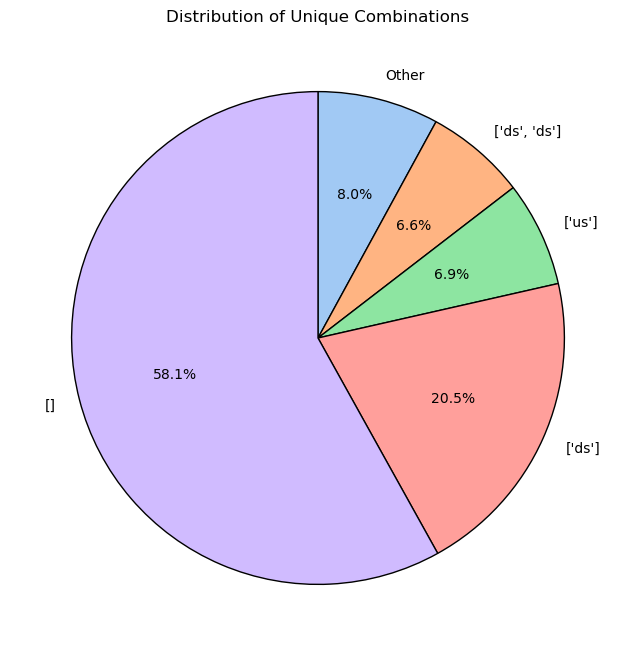

In [11]:
total_count = movement_counts["Count"].sum()

# 2% is considered the threshold, if the catagory has <2% = other
threshold = 0.02 * total_count

movement_counts["Category"] = np.where(movement_counts["Count"] < threshold, "Other", movement_counts["Combination"])
movement_counts["Combination"] = movement_counts["Combination"].astype(str)

movement_counts["Category"] = np.where(
    movement_counts["Count"] < threshold, "Other", movement_counts["Combination"]
)

pie_data = movement_counts.groupby("Category", as_index=False)["Count"].sum()

other_row = pie_data[pie_data["Category"] == "Other"]
pie_data = pie_data[pie_data["Category"] != "Other"]
pie_data = pie_data.sort_values(by="Count", ascending=True)

pie_data = pd.concat([other_row, pie_data], ignore_index=True)
custom_colors = sns.color_palette("pastel", len(pie_data))

plt.figure(figsize=(8,8))
plt.pie(pie_data["Count"], labels=pie_data["Category"], autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"}, counterclock=False, colors=custom_colors)
plt.title("Distribution of Unique Combinations")
plt.show()

In [12]:
# filter rows with any Timedelta > 30 days
more_than_30 = filtered_df[filtered_df['time_between_locations'].apply(
    lambda x: any(td > pd.Timedelta(days=30) for td in x if pd.notna(td))
)]

more_than_30

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_locations
178,982.000412,"[83, 84]","[5, 5]","[0 days 00:50:44.900000, 0 days 00:27:02.150000]",[us],"[171 days 07:33:44.040000, NaT]"
199,982.000412,"[83, 84]","[3, 1]","[0 days 00:19:01.560000, 0 days 00:00:00]",[us],"[120 days 01:29:17.290000, NaT]"
203,982.000412,"[83, 84]","[332, 26]","[0 days 18:00:58.240000, 0 days 21:40:09.280000]",[us],"[165 days 20:50:11.020000, NaT]"
206,982.000412,"[83, 84]","[12, 93]","[0 days 05:56:55.680000, 0 days 13:55:13.660000]",[us],"[179 days 10:07:17.170000, NaT]"
211,982.000412,"[83, 84]","[21, 1]","[1 days 22:07:23.800000, 0 days 00:00:00]",[us],"[66 days 00:19:26.060000, NaT]"
...,...,...,...,...,...,...
108395,989.002028,"[402, 45, 44, 45, 44, 45, 44, 45, 44, 45, 44, ...","[3, 3, 2, 1, 1, 2, 1, 1, 1, 98, 2, 1, 1, 1, 1]","[0 days 00:06:22.220000, 0 days 04:55:48.07000...","[us, ds, us, ds, us, ds, us, ds, us, ds, us, d...","[273 days 08:23:33.220000, 0 days 00:01:08, 0 ..."
108438,989.002028,"[402, 401, 402]","[1, 1, 124]","[0 days 00:00:00, 0 days 00:00:00, 0 days 04:3...","[ds, us]","[282 days 00:37:17.730000, 0 days 05:17:43.940..."
108839,989.002028,"[402, 401, 402, 401, 402, 401, 402, 401, 402, ...","[4, 7, 1, 1, 3, 73, 3, 2, 23, 1, 41, 1, 23, 1,...","[0 days 22:12:32.860000, 0 days 02:41:05.42000...","[ds, us, ds, us, ds, us, ds, us, ds, us, ds, u...","[1 days 00:26:21.140000, 0 days 21:27:48.27000..."
108889,989.002028,"[44, 45, 44]","[6, 2, 1]","[0 days 00:03:59.710000, 0 days 00:00:00, 0 da...","[us, ds]","[0 days 00:02:12.890000, 117 days 21:18:35.350..."


# Sankey attempt

In [15]:
sankey = more_than_30.loc[[178]] #taking random row
sankey['movement_direction'] = sankey['movement_direction'].apply(lambda x: x + [np.nan] if isinstance(x, list) else x)
# sankey['time_between_detections'] = sankey['time_between_detections'].apply(lambda x: x[:-1] if isinstance(x, list) and len(x) > 0 else x)
# sankey['time_between_detections'] = sankey['time_between_detections'].apply(lambda x: [np.nan] + x if isinstance(x, list) else x)

sankey

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_locations
178,982.000412,"[83, 84]","[5, 5]","[0 days 00:50:44.900000, 0 days 00:27:02.150000]","[us, nan]","[171 days 07:33:44.040000, NaT]"


In [16]:
columns_to_explode = ['loc_code', 'number_of_detections', 'movement_direction', 'time_between_locations']
sankey = sankey.explode(columns_to_explode)
sankey = pd.DataFrame(sankey)
sankey

,tag_id,loc_code,number_of_detections,dwell_time,movement_direction,time_between_locations
178,982.000412,83,5,"[0 days 00:50:44.900000, 0 days 00:27:02.150000]",us,171 days 07:33:44.040000
178,982.000412,84,5,"[0 days 00:50:44.900000, 0 days 00:27:02.150000]",NaN,NaT


In [17]:
type(sankey['time_between_locations'])

pandas.core.series.Series

In [18]:
# convert into sankey diagram format
source = sankey['loc_code'][0:len(sankey['loc_code'])-1]
target = sankey['loc_code'][1:len(sankey['loc_code'])]
value = sankey['number_of_detections'][0:len(sankey['loc_code'])-1] #change this to time between detections

sankey_df = {
    'Source' : source,
    'Target' : target,
    'Value' : value
}

sankey_df = pd.DataFrame(sankey_df)
sankey_df

,Source,Target,Value
178,83,84,5


In [19]:
import plotly.graph_objects as go

# # Sample data (Source, Target, Value)
# df_data = {
#     'Source': [84, 82, 84, 83 ],
#     'Target': [82, 84, 83, 84],
#     'Value': data['time_between_detections']
# }


labels = list(set(sankey_df['Source']).union(set(sankey_df['Target']))) # [83, 84, 82]
labels.sort()
label_to_index = {label: index for index, label in enumerate(labels)}  # {'83': 0, '84': 1, '82': 2}

# Prepare the Sankey data
sankey_data = {
    'type': 'sankey',
    'node': {
        'pad': 15,
        'thickness': 20,
        'line': {'color': "black", 'width': 0.5},
        'label': labels
    },
    'link': {
        'source': [label_to_index[source] for source in sankey_df['Source']],
        'target': [label_to_index[target] for target in sankey_df['Target']],
        'value': sankey_df['Value']
    }
}

# Create the figure
fig = go.Figure(go.Sankey(sankey_data))
fig.update_layout(title_text="Sankey Diagram", font_size=10)
fig.show()
